# Comparação de Velocidade: MDC por Euclides vs Checagem Consecutiva

Este notebook compara o tempo de execução de dois algoritmos para cálculo de MDC:

1. **Algoritmo de Euclides**
2. **Checagem consecutiva**

A análise é feita com entradas crescentes e visualização em gráfico, pronta para uso no Google Colab.

---

## 1) Configurar ambiente no Colab e importar bibliotecas

In [12]:
!pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jinja2]


In [14]:
import time
import math
import random
import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração visual e de reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')

# Parâmetros do experimento
TAMANHOS = [10**1, 10**2, 10**3, 2*10**3, 5*10**3, 10**4, 2*10**4, 5*10**4, 10**5, 2*10**5, 5*10**5, 10**6]
REPETICOES_EUCLIDES = 200
REPETICOES_CONSECUTIVO = 5

## 2) Implementar algoritmo de Euclides para MDC

Pseudocódigo de referência:

```text
input:(m,n)
while n ≠ 0 do
r ← m mod n;
m ← n;
n ← r;
return m;
```

In [3]:
def mdc_euclides(m: int, n: int) -> int:
    m, n = abs(m), abs(n)
    while n != 0:
        r = m % n
        m = n
        n = r
    return m

## 3) Implementar algoritmo de checagem consecutiva para MDC

Pseudocódigo de referência:

```text
input:(m,n)
i ← min(m,n)
while i ≠ 0 do
if (m mod i = 0 and n mod i = 0)
    return i;
i ← i - 1
```

In [4]:
def mdc_consecutivo(m: int, n: int) -> int:
    m, n = abs(m), abs(n)
    i = min(m, n)
    while i != 0:
        if (m % i == 0) and (n % i == 0):
            return i
        i -= 1
    return 0

## 4) Validar correção com casos de teste

Comparamos os dois algoritmos com `math.gcd` em casos variados (coprimos, múltiplos, valores iguais e diferentes magnitudes).

In [5]:
casos_teste = [
    (1, 1),
    (12, 18),
    (37, 600),
    (270, 192),
    (1024, 2048),
    (99991, 99989),
    (123456, 789012),
]

for m, n in casos_teste:
    g_ref = math.gcd(m, n)
    g_e = mdc_euclides(m, n)
    g_c = mdc_consecutivo(m, n)
    assert g_ref == g_e == g_c, f"Falha para ({m}, {n})"

print("Todos os testes passaram com sucesso.")

Todos os testes passaram com sucesso.


## 5) Gerar pares de entrada com valores crescentes

Usamos pares coprimos `(k+1, k)` para forçar um cenário desfavorável à checagem consecutiva e evidenciar a diferença de crescimento de tempo.

In [15]:
def gerar_pares_entrada(tamanhos):
    pares = []
    for k in tamanhos:
        pares.append((k + 1, k))
    return pares

pares_entrada = gerar_pares_entrada(TAMANHOS)
pares_entrada[:3], pares_entrada[-1]

([(11, 10), (101, 100), (1001, 1000)], (1000001, 1000000))

## 6) Medir tempo de execução dos algoritmos

A medição usa `time.perf_counter()` e calcula tempo médio por execução (em microssegundos) e desvio padrão para cada tamanho.

In [16]:
def medir_tempo_medio_us(func, m, n, repeticoes=30):
    tempos = []
    for _ in range(repeticoes):
        t0 = time.perf_counter()
        func(m, n)
        t1 = time.perf_counter()
        tempos.append((t1 - t0) * 1e6)  # microsegundos
    return statistics.mean(tempos), statistics.pstdev(tempos)

resultados = []

for tamanho, (m, n) in zip(TAMANHOS, pares_entrada):
    media_e, desvio_e = medir_tempo_medio_us(mdc_euclides, m, n, REPETICOES_EUCLIDES)
    media_c, desvio_c = medir_tempo_medio_us(mdc_consecutivo, m, n, REPETICOES_CONSECUTIVO)

    razao = media_c / media_e if media_e > 0 else float('inf')

    resultados.append({
        "tamanho_entrada": tamanho,
        "m": m,
        "n": n,
        "tempo_euclides_us": media_e,
        "tempo_checagem_us": media_c,
        "razao_checagem_div_euclides": razao,
        "desvio_euclides_us": desvio_e,
        "desvio_checagem_us": desvio_c,
    })

## 7) Organizar resultados em tabela

A tabela abaixo resume os tempos médios, desvios e a razão entre os algoritmos.

In [17]:
df_resultados = pd.DataFrame(resultados)

colunas_ordem = [
    "tamanho_entrada",
    "m",
    "n",
    "tempo_euclides_us",
    "tempo_checagem_us",
    "razao_checagem_div_euclides",
    "desvio_euclides_us",
    "desvio_checagem_us",
]

df_resultados = df_resultados[colunas_ordem]

df_resultados.style.format({
    "tempo_euclides_us": "{:.3f}",
    "tempo_checagem_us": "{:.3f}",
    "razao_checagem_div_euclides": "{:.2f}",
    "desvio_euclides_us": "{:.3f}",
    "desvio_checagem_us": "{:.3f}",
})

,tamanho_entrada,m,n,tempo_euclides_us,tempo_checagem_us,razao_checagem_div_euclides,desvio_euclides_us,desvio_checagem_us
0,10,11,10,0.258,1.500,5.81,0.316,1.158
1,100,101,100,0.212,4.808,22.63,0.043,0.148
2,1000,1001,1000,0.374,57.975,154.95,1.816,9.808
3,2000,2001,2000,0.218,106.058,486.67,0.046,9.195
4,5000,5001,5000,0.283,365.267,1290.22,1.339,179.986
5,10000,10001,10000,0.193,521.133,2706.41,0.054,58.931
6,20000,20001,20000,0.190,896.975,4733.13,0.056,22.319
7,50000,50001,50000,0.175,1939.408,11060.85,0.060,156.509
8,100000,100001,100000,0.134,3309.542,24668.62,0.030,132.216
9,200000,200001,200000,0.120,5496.941,45828.85,0.032,380.980


## 8) Plotar gráfico de tempo vs tamanho da entrada

Gráfico em escala linear para comparar os tempos médios dos dois métodos.

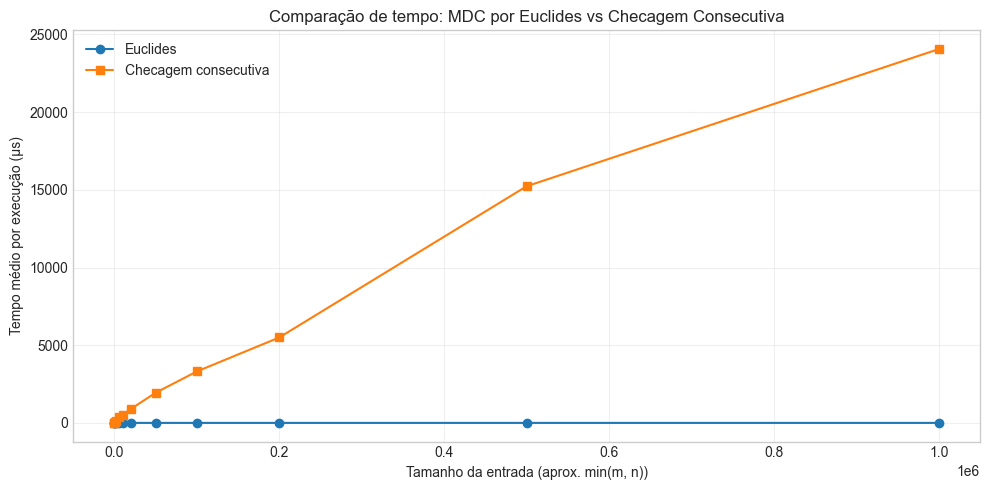

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df_resultados["tamanho_entrada"], df_resultados["tempo_euclides_us"], marker="o", label="Euclides")
plt.plot(df_resultados["tamanho_entrada"], df_resultados["tempo_checagem_us"], marker="s", label="Checagem consecutiva")
plt.xlabel("Tamanho da entrada (aprox. min(m, n))")
plt.ylabel("Tempo médio por execução (µs)")
plt.title("Comparação de tempo: MDC por Euclides vs Checagem Consecutiva")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9) Comparar crescimento de tempo em escala linear e logarítmica

A escala logarítmica no eixo y ajuda a visualizar melhor diferenças muito grandes entre os métodos.
Também exibimos a razão de tempos para quantificar quantas vezes a checagem consecutiva é mais lenta.

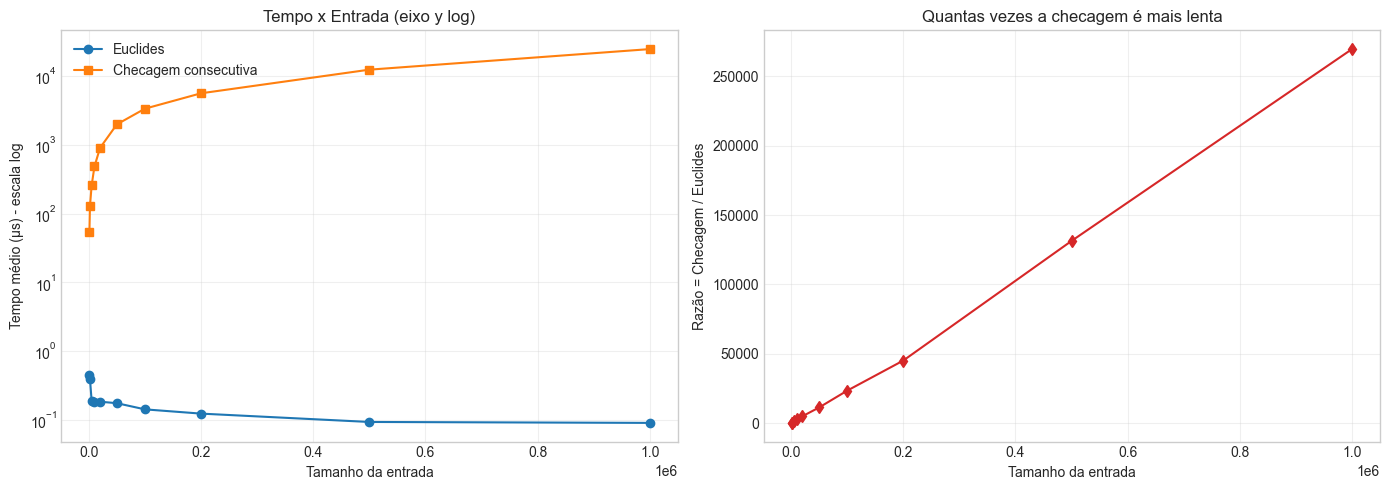

,tamanho_entrada,razao_checagem_div_euclides
7,200000,45084.070016
8,500000,131365.301590
9,1000000,269724.827105


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparação em escala logarítmica no eixo Y
axes[0].plot(df_resultados["tamanho_entrada"], df_resultados["tempo_euclides_us"], marker="o", label="Euclides")
axes[0].plot(df_resultados["tamanho_entrada"], df_resultados["tempo_checagem_us"], marker="s", label="Checagem consecutiva")
axes[0].set_yscale("log")
axes[0].set_xlabel("Tamanho da entrada")
axes[0].set_ylabel("Tempo médio (µs) - escala log")
axes[0].set_title("Tempo x Entrada (eixo y log)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Razão de tempos
axes[1].plot(df_resultados["tamanho_entrada"], df_resultados["razao_checagem_div_euclides"], marker="d", color="tab:red")
axes[1].set_xlabel("Tamanho da entrada")
axes[1].set_ylabel("Razão = Checagem / Euclides")
axes[1].set_title("Quantas vezes a checagem é mais lenta")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df_resultados[["tamanho_entrada", "razao_checagem_div_euclides"]].tail(3)

## Conclusão

- O algoritmo de **Euclides** apresenta crescimento de tempo muito menor com o aumento das entradas.
- A **checagem consecutiva** se torna rapidamente mais lenta, pois testa divisores de forma descendente até encontrar o MDC.
- Em entradas grandes, a diferença de desempenho pode chegar a várias ordens de magnitude, o que fica evidente no gráfico com eixo logarítmico.

> Em termos práticos, para aplicações reais com números maiores, o algoritmo de Euclides é a escolha recomendada.